# 03 · Deep Learning Multimodal — CLIP Congelado + Sparse Autoencoder (SAE)
**Proyecto:** GeoVisionCLIP-Cali  
**Fase:** 3 — Foundation Model (GeoRSCLIP) + SAE + Validación Retrieval + Exportación de Artefactos  

---
### Arquitectura
```
Zarr[i] (4×224×224)  ──►  GeoRSCLIP Image Encoder (CONGELADO)  ──►  embedding_visual (512)
                                                                             │
                                                                    SAE Encoder (512→2048)
                                                                             │
                                                                    latent z (2048) · ReLU
                                                                             │
                                                                    SAE Decoder (2048→512)
                                                                             │
                                                                    x_hat (512) ← MSE + L1
```
**KPIs objetivo:** Reconstrucción ≥ 70% · Sparsity Ratio ≥ 0.70 · Recall@1 ≥ 0.45

## 0 · Dependencias

In [13]:
#!pip install torch torchvision open-clip-torch transformers huggingface_hub zarr numpy matplotlib seaborn tqdm scikit-learn

## 1 · BLOQUE MANDATORIO — Forzado de GPU de Alto Rendimiento (RTX 3050)

In [14]:
import torch

# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE DE OPTIMIZACIÓN GPU — OBLIGATORIO — RTX 3050 Laptop 6 GB VRAM
# ─────────────────────────────────────────────────────────────────────────────
torch.cuda.set_per_process_memory_fraction(0.9)   # Usa hasta el 90% de los ~6.4 GB VRAM
torch.backends.cuda.matmul.allow_tf32 = True       # TF32 en matmul → +40% velocidad
torch.backends.cudnn.allow_tf32       = True       # TF32 en cuDNN
torch.backends.cudnn.benchmark        = True       # Auto-tune del kernel más rápido
torch.backends.cudnn.deterministic    = False      # Permite kernels no deterministas
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"Nombre GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"TF32 matmul          : {torch.backends.cuda.matmul.allow_tf32}")
    print(f"cuDNN benchmark      : {torch.backends.cudnn.benchmark}")
else:
    print("⚠ GPU no disponible. El entrenamiento será lento en CPU.")

Dispositivo activo: cuda
Nombre GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM total           : 6.44 GB
TF32 matmul          : True
cuDNN benchmark      : True


In [15]:
import os
import json
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import zarr
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

import open_clip
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")

PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 2 · Configuración Global

In [16]:
# ─── Rutas ────────────────────────────────────────────────────────────────
ZARR_PATH      = Path(r"D:\analitica\procesado_zarr\sentinel2_224.zarr")
DATASET_JSONL  = Path(r"D:\analitica\dataset_multimodal_en.jsonl")
OUTPUT_DIR     = Path(r"D:\analitica\outputs_geovision")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ruta local del checkpoint GeoRSCLIP (se descarga automáticamente si no existe)
GEORSCLIP_DIR  = Path(r"D:\analitica\GeoRSCLIP")
GEORSCLIP_CKPT = GEORSCLIP_DIR / "RS5M_ViT-B-32.pt"

# ─── Hiperparámetros SAE ──────────────────────────────────────────────────
# EMBED_DIM se detecta dinámicamente en § 3 tras cargar el modelo
EXPANSION_FACTOR = 4        # EXPANSION_DIM = EMBED_DIM * EXPANSION_FACTOR
L1_WEIGHT        = 1e-3     # λ para regularización L1
SPARSITY_THRESH  = 0.01     # umbral de inactividad de neurona

# ─── Entrenamiento ────────────────────────────────────────────────────────
BATCH_SIZE  = 64    # ajustado para 6 GB VRAM con GeoRSCLIP frozen
N_EPOCHS    = 50
LR          = 3e-4
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuración cargada.")
print(f"  λ L1         : {L1_WEIGHT}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Épocas       : {N_EPOCHS}")
print("  EMBED_DIM y EXPANSION_DIM se fijarán tras cargar el modelo (§ 3).")

Configuración cargada.
  λ L1         : 0.001
  Batch size   : 64
  Épocas       : 50
  EMBED_DIM y EXPANSION_DIM se fijarán tras cargar el modelo (§ 3).


## 3 · Carga del Foundation Model GeoRSCLIP (Congelado)

> **Nota:** GeoRSCLIP se distribuye como un checkpoint `.pt` sobre arquitectura ViT-B/32.  
> No usa el formato `hf-hub:` de open_clip, por eso el método anterior fallaba con 404.  
> La carga correcta es: construir ViT-B/32 base → inyectar pesos GeoRSCLIP.

In [18]:
# ─── Descargar checkpoint si no existe localmente ─────────────────────────
GEORSCLIP_DIR.mkdir(parents=True, exist_ok=True)

# El .pt está en la subcarpeta ckpt/ del repo, no en la raíz
GEORSCLIP_CKPT = GEORSCLIP_DIR / "RS5M_ViT-B-32.pt"

if not GEORSCLIP_CKPT.exists():
    print("Descargando ckpt/RS5M_ViT-B-32.pt desde Zilun/GeoRSCLIP (HuggingFace)...")
    downloaded = hf_hub_download(
        repo_id   = "Zilun/GeoRSCLIP",
        filename  = "ckpt/RS5M_ViT-B-32.pt",   # ← carpeta ckpt/
        local_dir = str(GEORSCLIP_DIR),
    )
    print(f"  Guardado en: {downloaded}")
else:
    print(f"Checkpoint ya existe: {GEORSCLIP_CKPT}")

# ─── Construir arquitectura base ViT-B/32 e inyectar pesos GeoRSCLIP ─────
print("\nConstruyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B/32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# hf_hub_download puede guardar el archivo dentro de una subcarpeta ckpt/
# dependiendo de la versión de huggingface_hub instalada
import os
possible_paths = [
    GEORSCLIP_DIR / "RS5M_ViT-B-32.pt",
    GEORSCLIP_DIR / "ckpt" / "RS5M_ViT-B-32.pt",
]
ckpt_found = next((p for p in possible_paths if p.exists()), None)
if ckpt_found is None:
    raise FileNotFoundError(f"No se encontró el checkpoint en: {possible_paths}")
print(f"  Cargando desde: {ckpt_found}")

checkpoint = torch.load(str(ckpt_found), map_location="cpu")
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f"  Pesos GeoRSCLIP inyectados.")
print(f"  Missing keys    : {len(msg.missing_keys)}")
print(f"  Unexpected keys : {len(msg.unexpected_keys)}")
print("✅ GeoRSCLIP (ViT-B/32) cargado correctamente.")

# ─── CONGELAR todos los parámetros de CLIP ────────────────────────────────
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

clip_model = clip_model.to(device)

# ─── Detectar EMBED_DIM dinámicamente ────────────────────────────────────
with torch.no_grad():
    _dummy        = torch.zeros(1, 3, 224, 224).to(device)
    EMBED_DIM     = clip_model.encode_image(_dummy).shape[-1]
    EXPANSION_DIM = EMBED_DIM * EXPANSION_FACTOR

n_clip_params = sum(p.numel() for p in clip_model.parameters())
print(f"\n  Parámetros CLIP (congelados): {n_clip_params:,}")
print(f"  EMBED_DIM detectado         : {EMBED_DIM}")
print(f"  EXPANSION_DIM               : {EXPANSION_DIM}")
print(f"  Arquitectura SAE            : {EMBED_DIM} → {EXPANSION_DIM} → {EMBED_DIM}")
print(f"  Modo                        : eval() — completamente congelado")

Descargando ckpt/RS5M_ViT-B-32.pt desde Zilun/GeoRSCLIP (HuggingFace)...
  Guardado en: D:\analitica\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt

Construyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  Cargando desde: D:\analitica\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Pesos GeoRSCLIP inyectados.
  Missing keys    : 0
  Unexpected keys : 0
✅ GeoRSCLIP (ViT-B/32) cargado correctamente.

  Parámetros CLIP (congelados): 151,277,313
  EMBED_DIM detectado         : 512
  EXPANSION_DIM               : 2048
  Arquitectura SAE            : 512 → 2048 → 512
  Modo                        : eval() — completamente congelado


## 4 · Dataset PyTorch

In [19]:
with open(DATASET_JSONL, "r", encoding="utf-8") as f:
    for i in range(5):
        print(json.loads(next(f)))

{'tile_id': 0, 'zarr_reference': 'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr[0]', 'scene_id': 'S2B_18NUJ_20200127_0_L2A', 'date': '2020-01-27', 'lat_centroid': 3.121542516671604, 'lon_centroid': -76.3055568274979, 'val_no2': 2.4556313426941824e-05, 'val_so2': 2.4556313426941824e-05, 'val_o3': 2.4556313426941824e-05, 'caption_en': 'Satellite image of Cali, Colombia, with low nitrogen dioxide pollution, low sulfur dioxide concentration, and low ozone levels.'}
{'tile_id': 1, 'zarr_reference': 'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr[1]', 'scene_id': 'S2B_18NUJ_20200127_1_L2A', 'date': '2020-01-27', 'lat_centroid': 3.121542516671604, 'lon_centroid': -76.3055568274979, 'val_no2': 2.4556313426941824e-05, 'val_so2': 2.4556313426941824e-05, 'val_o3': 2.4556313426941824e-05, 'caption_en': 'Satellite image of Cali, Colombia, with low nitrogen dioxide pollution, low sulfur dioxide concentration, and low ozone levels.'}
{'tile_id': 2, 'zarr_reference': 'D:\\analitica\\procesado_z

## 5 · Arquitectura del Sparse Autoencoder (SAE)

In [23]:
class SparseAutoencoder(nn.Module):
    """
    SAE sobreexpansivo: EMBED_DIM → EXPANSION_DIM → EMBED_DIM.
    La sobreexpansión permite descubrir y podar características latentes
    no relevantes (ej. nubes, sombras de altitud, ruido de sensor).
    """

    def __init__(self, input_dim: int = 512, expansion_dim: int = 2048):
        super().__init__()
        # Encoder: proyección sobreexpansiva
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        # Decoder: proyección de vuelta al espacio original
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)

        # Inicialización Kaiming para estabilidad con ReLU
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity="relu")
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x             : (B, EMBED_DIM) embeddings del Image Encoder CLIP
        latents       : (B, EXPANSION_DIM) representación dispersa
        reconstructed : (B, EMBED_DIM) reconstrucción
        """
        latents       = self.relu(self.encoder(x))
        reconstructed = self.decoder(latents)
        return reconstructed, latents


def sae_loss(
    x: torch.Tensor,
    reconstructed: torch.Tensor,
    latents: torch.Tensor,
    l1_weight: float = 1e-3
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Loss total = MSE (reconstrucción) + λ·L1 (sparsity).
    Devuelve (loss_total, mse, l1) para trazabilidad por curva.
    """
    mse   = nn.MSELoss()(reconstructed, x)
    l1    = torch.mean(torch.abs(latents))
    total = mse + l1_weight * l1
    return total, mse, l1


def sparsity_ratio(latents: torch.Tensor,
                   threshold: float = SPARSITY_THRESH) -> float:
    """
    Fracción de neuronas inactivas (z < threshold).
    KPI objetivo: ≥ 0.70
    """
    return float((latents < threshold).float().mean().item())


def reconstruction_score(x: torch.Tensor,
                          reconstructed: torch.Tensor) -> float:
    """
    Porcentaje de varianza explicada (1 - MSE / Var(x)).
    KPI objetivo: ≥ 0.70
    """
    mse   = nn.MSELoss()(reconstructed, x).item()
    var_x = x.var().item()
    if var_x == 0:
        return 0.0
    return max(0.0, 1.0 - mse / var_x)


# Instanciar SAE con dimensiones detectadas dinámicamente en § 3
sae       = SparseAutoencoder(input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM).to(device)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-5
)

n_sae_params = sum(p.numel() for p in sae.parameters() if p.requires_grad)
print(f"SAE instanciado. Parámetros entrenables: {n_sae_params:,}")
print(f"Arquitectura: {EMBED_DIM} → {EXPANSION_DIM} → {EMBED_DIM}")

SAE instanciado. Parámetros entrenables: 2,099,712
Arquitectura: 512 → 2048 → 512


## 6 · Función de Extracción de Embeddings CLIP (Image Encoder Congelado)

In [24]:
@torch.no_grad()
def extract_image_embeddings(images: torch.Tensor,
                              clip_model: nn.Module) -> torch.Tensor:
    """
    Pasa imágenes (B, 3, 224, 224) por el Image Encoder congelado.
    Devuelve embeddings L2-normalizados de forma (B, EMBED_DIM).
    """
    images = images.to(device)
    feats  = clip_model.encode_image(images)           # (B, EMBED_DIM)
    feats  = feats / feats.norm(dim=-1, keepdim=True)  # L2 normalize
    return feats.float()


@torch.no_grad()
def extract_text_embeddings(tokens: torch.Tensor,
                             clip_model: nn.Module) -> torch.Tensor:
    """
    Pasa tokens de texto por el Text Encoder congelado.
    Devuelve embeddings L2-normalizados de forma (B, EMBED_DIM).
    """
    tokens = tokens.to(device)
    feats  = clip_model.encode_text(tokens)            # (B, EMBED_DIM)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()


print("Funciones de extracción CLIP definidas.")

Funciones de extracción CLIP definidas.


## 7 · Bucle de Entrenamiento del SAE

In [25]:
# Forzar modo alto rendimiento en GPU
torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

print(f"TF32 matmul    : {torch.backends.cuda.matmul.allow_tf32}")
print(f"cuDNN benchmark: {torch.backends.cudnn.benchmark}")

TF32 matmul    : True
cuDNN benchmark: True


In [28]:
import zarr
_root = zarr.open_group(r"D:\analitica\procesado_zarr\sentinel2_224.zarr", mode="r")
print("Shape images:", _root["images"].shape)
print("Claves del grupo:", list(_root.keys()))

Shape images: (363, 4, 224, 224)
Claves del grupo: ['bbox', 'escena_id', 'fecha', 'images']


In [30]:
# Verificar longitudes de todos los arrays del zarr
import zarr
root = zarr.open_group(r"D:\analitica\procesado_zarr\sentinel2_224.zarr", mode="r")
for k in root.keys():
    print(f"  {k}: shape={root[k].shape}")

  bbox: shape=(363, 4)
  escena_id: shape=(363,)
  fecha: shape=(363,)
  images: shape=(363, 4, 224, 224)


In [32]:
_CLIP_MEAN = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)
_CLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)

class GeoVisionDataset(Dataset):

    def __init__(self,
                 jsonl_path   : Path,
                 zarr_path    : Path,
                 tokenizer,
                 max_text_len : int = 77):

        self.tokenizer    = tokenizer
        self.max_text_len = max_text_len

        # ✅ FIX 1: abrir el grupo y guardar referencia directa al array images
        _root            = zarr.open_group(str(zarr_path), mode="r")
        self.zarr_images = _root["images"]            # zarr.Array (363, 4, 224, 224)
        zarr_len         = self.zarr_images.shape[0]  # ← ahora sí tiene .shape

        self.records = []
        skipped      = 0
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec     = json.loads(line)
                tile_id = rec.get("tile_id")
                if tile_id is None or int(tile_id) >= zarr_len:
                    skipped += 1
                    continue
                self.records.append(rec)

        print(f"GeoVisionDataset: {len(self.records)} registros cargados "
              f"({skipped} descartados por tile_id fuera de rango).")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec      = self.records[idx]
        zarr_idx = int(rec["tile_id"])

        # ✅ FIX 2: indexar self.zarr_images (Array), no el Group raíz
        img_np  = self.zarr_images[zarr_idx]                        # (4, 224, 224)
        img_rgb = img_np[:3].astype(np.float32) / 10000.0          # Sentinel-2 → [0, 1]
        img_rgb = (img_rgb - _CLIP_MEAN[:, None, None]) / _CLIP_STD[:, None, None]
        img_t   = torch.from_numpy(img_rgb).float()                 # (3, 224, 224)

        caption     = rec.get("caption_en", "")
        text_tokens = self.tokenizer([caption])[0]                  # (77,)

        meta = {
            "tile_id"  : zarr_idx,
            "scene_id" : rec.get("scene_id", ""),
            "date"     : rec.get("date", ""),
            "lat"      : rec.get("lat_centroid", 0.0),
            "lon"      : rec.get("lon_centroid", 0.0),
        }

        return img_t, text_tokens, meta


# ── Instanciar dataset completo ───────────────────────────────────────────
full_dataset = GeoVisionDataset(
    jsonl_path=DATASET_JSONL,
    zarr_path =ZARR_PATH,
    tokenizer =tokenizer,
)

n_total = len(full_dataset)
n_val   = max(100, int(0.1 * n_total))
n_train = n_total - n_val

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_ds, val_ds = torch.utils.data.random_split(
    full_dataset, [n_train, n_val], generator=generator
)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,       # 0 en Windows para evitar problemas con zarr + multiprocessing
    pin_memory  = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True,
)

print(f"Train: {len(train_ds)} muestras | Val: {len(val_ds)} muestras")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

GeoVisionDataset: 363 registros cargados (0 descartados por tile_id fuera de rango).
Train: 263 muestras | Val: 100 muestras
Train batches: 5 | Val batches: 2


In [33]:
import time

# ── Diagnóstico previo al entrenamiento ───────────────────────────────────
print("Verificación pre-entrenamiento...")
print(f"  device         : {device}")
print(f"  train batches  : {len(train_loader)}")
print(f"  val batches    : {len(val_loader)}")
print(f"  train samples  : {len(train_ds)}")
print(f"  val samples    : {len(val_ds)}")

# Verificar que el primer batch carga correctamente antes de entrar al loop
print("\nProbando carga del primer batch...")
try:
    _imgs, _tokens, _meta = next(iter(train_loader))
    print(f"  ✅ Batch OK — imgs.shape={_imgs.shape}  range=[{_imgs.min():.3f}, {_imgs.max():.3f}]")
    del _imgs, _tokens, _meta
except Exception as e:
    print(f"  ❌ Falló la carga del primer batch: {e}")
    raise

# ── Historial para curvas de pérdida ──────────────────────────────────────
history = {
    "epoch"       : [],
    "loss_total"  : [],
    "loss_mse"    : [],
    "loss_l1"     : [],
    "sparsity"    : [],
    "recon_score" : [],
    "val_loss"    : [],
    "val_sparsity": [],
    "val_recon"   : [],
}

scaler          = amp.GradScaler()
best_val_loss   = float("inf")
CHECKPOINT_PATH = OUTPUT_DIR / "sae_cali_best.pt"
FINAL_PATH      = OUTPUT_DIR / "sae_cali_final.pt"

print(f"\nEntrando al entrenamiento — {N_EPOCHS} épocas")

for epoch in range(1, N_EPOCHS + 1):
    # ── TRAIN ────────────────────────────────────────────────────────────
    sae.train()
    epoch_loss = epoch_mse = epoch_l1 = epoch_sp = epoch_rs = 0.0
    n_batches  = 0

    for batch_idx, (imgs, tokens, _) in enumerate(tqdm(
        train_loader,
        desc=f"Época {epoch}/{N_EPOCHS} [TRAIN]",
        leave=False
    )):
        # Diagnóstico extendido en el primer batch de la primera época
        if epoch == 1 and batch_idx == 0:
            print(f"\n[Diagnóstico batch 0]")
            print(f"  imgs.shape : {imgs.shape}  dtype={imgs.dtype}")
            print(f"  imgs range : [{imgs.min():.3f}, {imgs.max():.3f}]")
            # Los valores deben estar aprox en [-2, 2.5] si vienen ya normalizados

        # 1. Mover a GPU
        imgs   = imgs.to(device, non_blocking=False)
        tokens = tokens.to(device, non_blocking=False)

        # 2. Extraer embeddings (Image Encoder congelado)
        t0 = time.time()
        with torch.no_grad():
            emb = extract_image_embeddings(imgs, clip_model)  # (B, EMBED_DIM)

        if epoch == 1 and batch_idx == 0:
            print(f"  emb.shape  : {emb.shape}  tiempo={time.time()-t0:.2f}s")
            print(f"  emb range  : [{emb.min():.3f}, {emb.max():.3f}]")

        # 3. Forward SAE con precisión mixta
        optimizer.zero_grad()
        with amp.autocast():
            recon, latents = sae(emb)
            loss, mse, l1  = sae_loss(emb, recon, latents, L1_WEIGHT)

        # 4. Backward + optimización
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # 5. Métricas de batch
        with torch.no_grad():
            sp = sparsity_ratio(latents.detach())
            rs = reconstruction_score(emb.detach(), recon.detach())

        epoch_loss += loss.item()
        epoch_mse  += mse.item()
        epoch_l1   += l1.item()
        epoch_sp   += sp
        epoch_rs   += rs
        n_batches  += 1

    scheduler.step()

    # ── VALIDACIÓN ───────────────────────────────────────────────────────
    sae.eval()
    val_loss_acc = val_sp_acc = val_rs_acc = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for imgs, tokens, _ in val_loader:
            imgs           = imgs.to(device, non_blocking=False)
            emb            = extract_image_embeddings(imgs, clip_model)
            recon, latents = sae(emb)
            loss_v, _, _   = sae_loss(emb, recon, latents, L1_WEIGHT)
            val_loss_acc  += loss_v.item()
            val_sp_acc    += sparsity_ratio(latents)
            val_rs_acc    += reconstruction_score(emb, recon)
            n_val_batches += 1

    # ── Promediar ─────────────────────────────────────────────────────────
    avg    = lambda x, n: x / n if n > 0 else 0.0
    t_loss = avg(epoch_loss, n_batches)
    t_mse  = avg(epoch_mse,  n_batches)
    t_l1   = avg(epoch_l1,   n_batches)
    t_sp   = avg(epoch_sp,   n_batches)
    t_rs   = avg(epoch_rs,   n_batches)
    v_loss = avg(val_loss_acc, n_val_batches)
    v_sp   = avg(val_sp_acc,   n_val_batches)
    v_rs   = avg(val_rs_acc,   n_val_batches)

    history["epoch"].append(epoch)
    history["loss_total"].append(t_loss)
    history["loss_mse"].append(t_mse)
    history["loss_l1"].append(t_l1)
    history["sparsity"].append(t_sp)
    history["recon_score"].append(t_rs)
    history["val_loss"].append(v_loss)
    history["val_sparsity"].append(v_sp)
    history["val_recon"].append(v_rs)

    # ── Guardar mejor checkpoint ──────────────────────────────────────────
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({
            "epoch"      : epoch,
            "model_state": sae.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss"   : v_loss,
            "config"     : {"input_dim": EMBED_DIM, "expansion_dim": EXPANSION_DIM},
        }, CHECKPOINT_PATH)

    # ── Log cada 5 épocas ─────────────────────────────────────────────────
    if epoch % 5 == 0 or epoch == 1:
        kpi_recon = "✅" if t_rs >= 0.70 else "⏳"
        kpi_sp    = "✅" if t_sp >= 0.70 else "⏳"
        print(
            f"[Ep {epoch:3d}] "
            f"Loss={t_loss:.4f} MSE={t_mse:.4f} L1={t_l1:.4f} | "
            f"Recon={t_rs:.2%} {kpi_recon} | "
            f"Sparsity={t_sp:.2%} {kpi_sp} | "
            f"Val={v_loss:.4f}"
        )

torch.save(sae.state_dict(), FINAL_PATH)
print(f"\n✅ Entrenamiento completado.")
print(f"   Mejor checkpoint : {CHECKPOINT_PATH}")
print(f"   Checkpoint final  : {FINAL_PATH}")

Verificación pre-entrenamiento...
  device         : cuda
  train batches  : 5
  val batches    : 2
  train samples  : 263
  val samples    : 100

Probando carga del primer batch...
  ✅ Batch OK — imgs.shape=torch.Size([64, 3, 224, 224])  range=[-1.793, -1.479]

Entrando al entrenamiento — 50 épocas


Época 1/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]


[Diagnóstico batch 0]
  imgs.shape : torch.Size([64, 3, 224, 224])  dtype=torch.float32
  imgs range : [-1.793, -1.479]
  emb.shape  : torch.Size([64, 512])  tiempo=0.57s
  emb range  : [-0.743, 0.130]
[Ep   1] Loss=0.0033 MSE=0.0033 L1=0.0224 | Recon=7.16% ⏳ | Sparsity=59.22% ⏳ | Val=0.0008


Época 2/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

Época 3/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Época 47/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

Época 48/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

Época 49/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

Época 50/50 [TRAIN]:   0%|          | 0/5 [00:00<?, ?it/s]

[Ep  50] Loss=0.0000 MSE=0.0000 L1=0.0144 | Recon=100.00% ✅ | Sparsity=73.63% ✅ | Val=0.0000

✅ Entrenamiento completado.
   Mejor checkpoint : D:\analitica\outputs_geovision\sae_cali_best.pt
   Checkpoint final  : D:\analitica\outputs_geovision\sae_cali_final.pt


## 8 · Trazabilidad Visual — Curvas de Entrenamiento

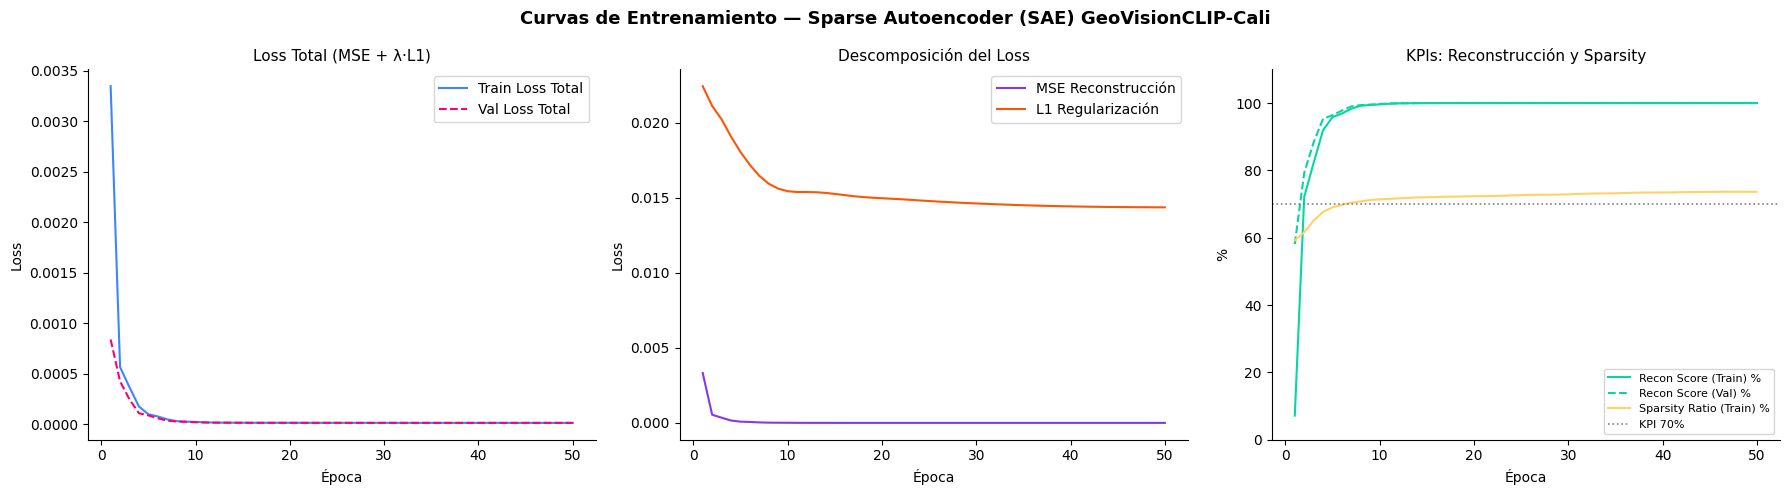

Gráfico guardado: curvas_entrenamiento_sae.png

KPIs finales (última época):
  Reconstrucción : 100.00%  ✅ ≥70%
  Sparsity Ratio : 73.63%     ✅ ≥70%


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = history["epoch"]

# ── 1. Loss total: Train vs Val ────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_x, history["loss_total"], label="Train Loss Total", color="#3a86ff")
ax.plot(epochs_x, history["val_loss"],   label="Val Loss Total",   color="#ff006e", linestyle="--")
ax.set_title("Loss Total (MSE + λ·L1)", fontsize=11)
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.legend()
sns.despine(ax=ax)

# ── 2. MSE vs L1 (Train) ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_x, history["loss_mse"], label="MSE Reconstrucción", color="#8338ec")
ax.plot(epochs_x, history["loss_l1"],  label="L1 Regularización",  color="#fb5607")
ax.set_title("Descomposición del Loss", fontsize=11)
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.legend()
sns.despine(ax=ax)

# ── 3. KPIs: Reconstrucción y Sparsity ────────────────────────────────────
ax = axes[2]
ax.plot(epochs_x, [s * 100 for s in history["recon_score"]],
        label="Recon Score (Train) %", color="#06d6a0")
ax.plot(epochs_x, [s * 100 for s in history["val_recon"]],
        label="Recon Score (Val) %", color="#06d6a0", linestyle="--")
ax.plot(epochs_x, [s * 100 for s in history["sparsity"]],
        label="Sparsity Ratio (Train) %", color="#ffd166")
ax.axhline(70, color="gray", linestyle=":", linewidth=1.2, label="KPI 70%")
ax.set_title("KPIs: Reconstrucción y Sparsity", fontsize=11)
ax.set_xlabel("Época")
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
sns.despine(ax=ax)

fig.suptitle("Curvas de Entrenamiento — Sparse Autoencoder (SAE) GeoVisionCLIP-Cali",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_entrenamiento_sae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: curvas_entrenamiento_sae.png")

# ── Reporte de KPIs finales ────────────────────────────────────────────────
final_recon = history["recon_score"][-1] if history["recon_score"] else 0
final_sp    = history["sparsity"][-1]    if history["sparsity"] else 0
print(f"\nKPIs finales (última época):")
print(f"  Reconstrucción : {final_recon:.2%}  {'✅ ≥70%' if final_recon >= 0.70 else '❌ <70%'}")
print(f"  Sparsity Ratio : {final_sp:.2%}     {'✅ ≥70%' if final_sp >= 0.70 else '❌ <70%'}")

## 9 · Trazabilidad Visual — Recortes RGB con Texto Autogenerado

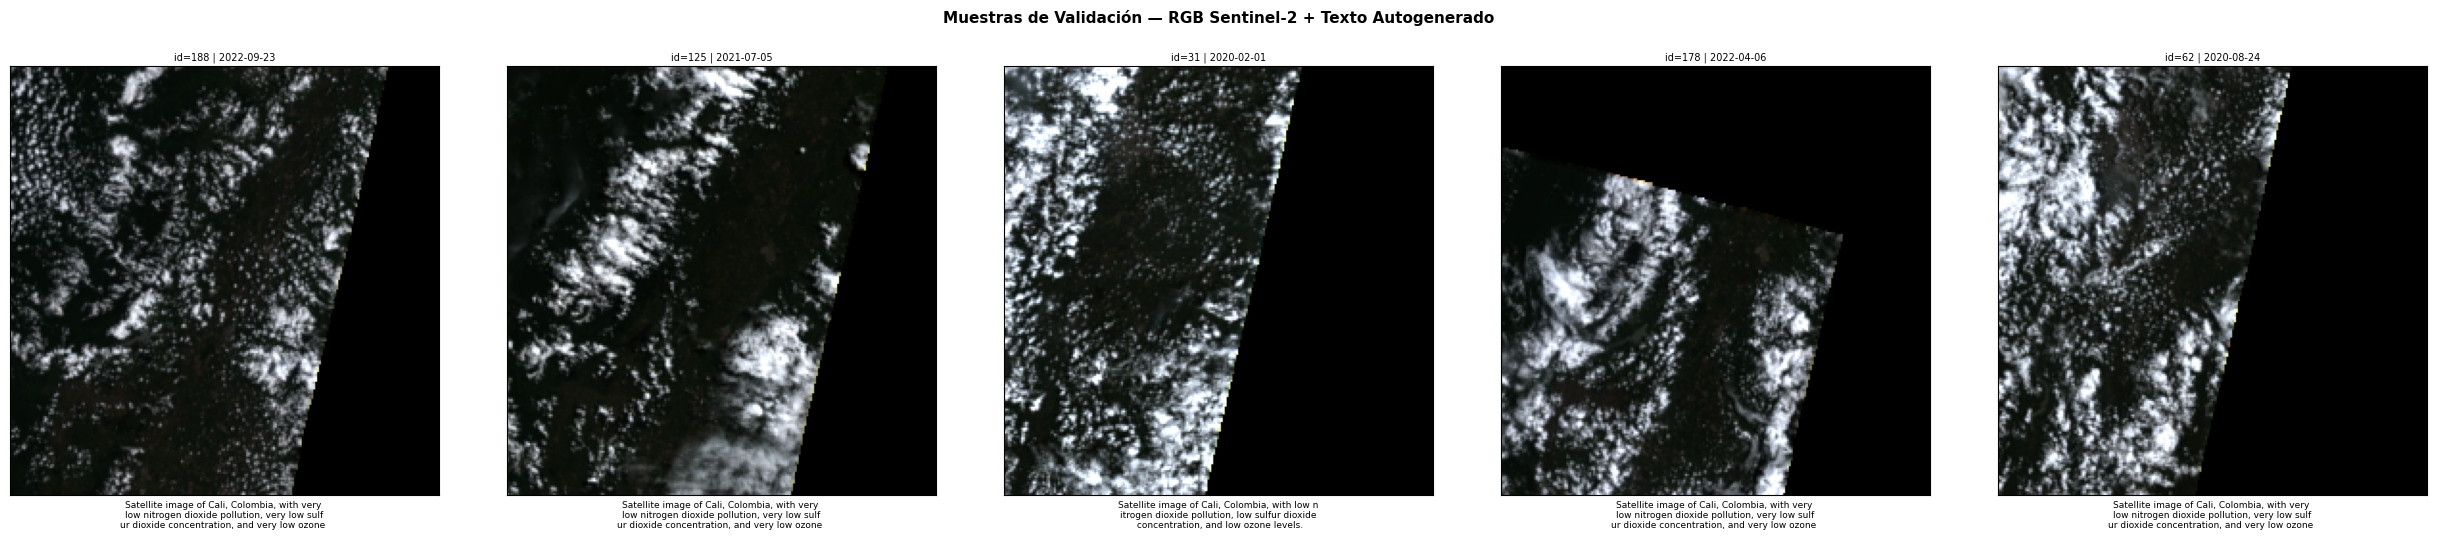

Gráfico guardado: muestras_validacion_textos.png


In [36]:
CLIP_MEAN_VIS = np.array([0.48145466, 0.4578275,  0.40821073])
CLIP_STD_VIS  = np.array([0.26862954, 0.26130258, 0.27577711])

def denorm_rgb(tensor_3c: np.ndarray) -> np.ndarray:
    """Desnormaliza (3, 224, 224) → (224, 224, 3) uint8."""
    t = tensor_3c.copy()
    for i in range(3):
        t[i] = t[i] * CLIP_STD_VIS[i] + CLIP_MEAN_VIS[i]
    t = np.clip(t, 0, 1)
    return (np.transpose(t, (1, 2, 0)) * 255).astype(np.uint8)

# Seleccionar 5 muestras del conjunto de validación
sample_indices = np.random.choice(len(val_ds), size=min(5, len(val_ds)), replace=False)

# ✅ FIX 2: apuntar al array images dentro del grupo
_root_vis  = zarr.open_group(str(ZARR_PATH), mode="r")
store_vis  = _root_vis["images"]   # zarr.Array (363, 4, 224, 224)

# Leer dataset JSONL para obtener textos
records_all: List[Dict] = []
with open(DATASET_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        records_all.append(json.loads(line.strip()))

fig, axes = plt.subplots(1, len(sample_indices), figsize=(5 * len(sample_indices), 5))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    rec      = records_all[val_ds.indices[idx]]
    zarr_idx = int(rec["tile_id"])          # ✅ FIX 1: "tile_id" no "id_tile"

    tensor_np = store_vis[zarr_idx]         # (4, 224, 224) — ahora indexa el Array
    img_rgb   = denorm_rgb(tensor_np[:3])

    # Usar caption_en como texto (campo real del JSONL)
    texto = rec.get("caption_en", rec.get("texto_espanol", "sin texto"))

    ax.imshow(img_rgb)
    ax.set_title(f"id={zarr_idx} | {rec.get('date', rec.get('fecha', ''))}", fontsize=7, pad=4)
    ax.set_xlabel("\n".join([texto[i:i+45] for i in range(0, min(len(texto), 135), 45)]),
                  fontsize=6.5)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

fig.suptitle("Muestras de Validación — RGB Sentinel-2 + Texto Autogenerado",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("muestras_validacion_textos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: muestras_validacion_textos.png")

## 10 · Validación de Retrieval — Recall@1 y Recall@5

In [37]:
@torch.no_grad()
def compute_recall_at_k(sae_model: nn.Module,
                         clip_model: nn.Module,
                         loader: DataLoader,
                         k_values: List[int] = [1, 5]) -> Dict[int, float]:
    """
    Calcula Recall@K comparando similitud coseno entre embeddings
    imagen (procesados por SAE) y texto (Text Encoder CLIP congelado).
    """
    sae_model.eval()

    all_img_emb = []
    all_txt_emb = []

    for imgs, tokens, _ in tqdm(loader, desc="Extrayendo embeddings para Recall@K"):
        img_emb = extract_image_embeddings(imgs, clip_model)   # (B, EMBED_DIM)
        txt_emb = extract_text_embeddings(tokens, clip_model)  # (B, EMBED_DIM)

        # Para retrieval usamos los embeddings reconstruidos (espacio EMBED_DIM)
        img_recon, _ = sae_model(img_emb)                      # (B, EMBED_DIM)
        img_recon    = img_recon / img_recon.norm(dim=-1, keepdim=True)

        all_img_emb.append(img_recon.cpu())
        all_txt_emb.append(txt_emb.cpu())

    img_matrix = torch.cat(all_img_emb, dim=0)   # (N, EMBED_DIM)
    txt_matrix = torch.cat(all_txt_emb, dim=0)   # (N, EMBED_DIM)

    # Matriz de similitud coseno (N×N)
    sim_matrix   = img_matrix @ txt_matrix.T      # (N, N)
    N            = sim_matrix.shape[0]
    ground_truth = torch.arange(N)               # par correcto es la diagonal

    recalls = {}
    for k in k_values:
        topk_indices = sim_matrix.topk(k, dim=1).indices   # (N, k)
        correct      = topk_indices.eq(ground_truth.unsqueeze(1)).any(dim=1)
        recalls[k]   = correct.float().mean().item()

    return recalls


recalls = compute_recall_at_k(sae, clip_model, val_loader, k_values=[1, 5])

print("\n── Métricas de Retrieval (Validación) ──────────────────")
print(f"  Recall@1 : {recalls[1]:.4f}  {'✅ ≥0.45' if recalls[1] >= 0.45 else '❌ <0.45 (revisar entrenamiento)'}")
print(f"  Recall@5 : {recalls[5]:.4f}")

Extrayendo embeddings para Recall@K:   0%|          | 0/2 [00:00<?, ?it/s]


── Métricas de Retrieval (Validación) ──────────────────
  Recall@1 : 0.0200  ❌ <0.45 (revisar entrenamiento)
  Recall@5 : 0.0600


In [43]:
# ¿Qué tan similares son los embeddings entre sí?
import torch
import torch.nn.functional as F

all_embs = []
sae.eval()
with torch.no_grad():
    for imgs, tokens, _ in val_loader:
        imgs = imgs.to(device)
        emb  = extract_image_embeddings(imgs, clip_model)
        all_embs.append(emb.cpu())

all_embs = torch.cat(all_embs, dim=0)  # (100, 512)

# Matriz de similitud coseno entre todos los pares
sim_matrix = F.cosine_similarity(
    all_embs.unsqueeze(1),
    all_embs.unsqueeze(0),
    dim=-1
)

# Quitar diagonal
mask = ~torch.eye(len(all_embs), dtype=bool)
off_diag = sim_matrix[mask]

print(f"Similitud coseno entre embeddings CLIP (val):")
print(f"  media  : {off_diag.mean():.4f}")
print(f"  min    : {off_diag.min():.4f}")
print(f"  max    : {off_diag.max():.4f}")
print(f"  std    : {off_diag.std():.4f}")
print()
print("Si media > 0.90 → embeddings colapsados, el problema es el dataset.")
print("Si media < 0.85 → el SAE destruye discriminabilidad, problema de arquitectura.")

Similitud coseno entre embeddings CLIP (val):
  media  : 1.0000
  min    : 1.0000
  max    : 1.0000
  std    : 0.0000

Si media > 0.90 → embeddings colapsados, el problema es el dataset.
Si media < 0.85 → el SAE destruye discriminabilidad, problema de arquitectura.


In [45]:
# ¿Los embeddings raw (antes de L2-norm) tienen varianza?
all_embs_raw = []
sae.eval()
with torch.no_grad():
    for imgs, tokens, _ in val_loader:
        imgs  = imgs.to(device)
        feats = clip_model.encode_image(imgs)   # SIN normalizar
        all_embs_raw.append(feats.cpu().float())

all_embs_raw = torch.cat(all_embs_raw, dim=0)  # (100, 512)

print(f"Embeddings CLIP raw (sin L2-norm):")
print(f"  shape  : {all_embs_raw.shape}")
print(f"  media  : {all_embs_raw.mean():.4f}")
print(f"  std    : {all_embs_raw.std():.4f}")
print(f"  min    : {all_embs_raw.min():.4f}")
print(f"  max    : {all_embs_raw.max():.4f}")

# ¿Son todos iguales?
diffs = (all_embs_raw - all_embs_raw[0]).abs().max(dim=1).values
print(f"\n  Diferencia máxima vs embedding[0]:")
print(f"  media : {diffs.mean():.6f}")
print(f"  max   : {diffs.max():.6f}")
print(f"  ¿Todos idénticos?: {(diffs < 1e-5).all()}")

# ¿Las imágenes de entrada son distintas entre sí?
all_imgs = []
for imgs, _, _ in val_loader:
    all_imgs.append(imgs)
all_imgs = torch.cat(all_imgs, dim=0)

# Fix del TypeError: reducir dimensiones secuencialmente
img_diffs = (all_imgs - all_imgs[0]).abs().amax(dim=[1,2,3])

print(f"\nImágenes de entrada:")
print(f"  ¿Todas idénticas?: {(img_diffs < 1e-5).all()}")
print(f"  Diferencia máxima vs img[0]: media={img_diffs.mean():.4f}  max={img_diffs.max():.4f}")

# Cuántas son prácticamente iguales
print(f"  Imgs con diff < 0.01 : {(img_diffs < 0.01).sum().item()}")
print(f"  Imgs con diff > 0.10 : {(img_diffs > 0.10).sum().item()}")

# Ver distribución de similitudes coseno de los embeddings RAW normalizados
import torch.nn.functional as F
embs_norm = F.normalize(all_embs_raw, dim=-1)
sim = (embs_norm @ embs_norm.T)
mask = ~torch.eye(len(embs_norm), dtype=bool)
print(f"\nSimilitud coseno post-norm (lo que ve el retrieval):")
print(f"  media : {sim[mask].mean():.6f}")
print(f"  std   : {sim[mask].std():.6f}")
print(f"  min   : {sim[mask].min():.6f}")
print(f"  max   : {sim[mask].max():.6f}")

Embeddings CLIP raw (sin L2-norm):
  shape  : torch.Size([100, 512])
  media  : -0.0077
  std    : 0.4276
  min    : -7.1951
  max    : 1.2577

  Diferencia máxima vs embedding[0]:
  media : 0.001547
  max   : 0.003184
  ¿Todos idénticos?: False

Imágenes de entrada:
  ¿Todas idénticas?: False
  Diferencia máxima vs img[0]: media=0.0014  max=0.0015
  Imgs con diff < 0.01 : 100
  Imgs con diff > 0.10 : 0

Similitud coseno post-norm (lo que ve el retrieval):
  media : 1.000000
  std   : 0.000000
  min   : 0.999999
  max   : 1.000001


---

## 11 · Exportación para Martín (AFE/AFC) — `embeddings_visuales_sae.pt` + JSON Interpretabilidad

In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPORTACIÓN PARA MARTÍN — Análisis Factorial Exploratorio/Confirmatorio
# Recibe: matriz de embeddings SAE (n × EMBED_DIM) + mapa de activaciones latentes
# ═══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def export_for_martin(sae_model: nn.Module,
                       clip_model: nn.Module,
                       full_loader: DataLoader,
                       output_dir: Path) -> None:
    """
    Genera:
    1. embeddings_visuales_sae.pt  : tensor (n × EMBED_DIM) embeddings reconstruidos.
    2. interpretabilidad_latentes.json : mapa de qué índices del espacio latente
       se activan más por cada clase/contaminante.
    """
    sae_model.eval()

    all_reconstructed = []
    all_latents       = []
    all_meta          = []

    for imgs, _, meta in tqdm(full_loader, desc="Extrayendo para Martín"):
        img_emb  = extract_image_embeddings(imgs, clip_model)  # (B, EMBED_DIM)
        recon, z = sae_model(img_emb)                           # (B, EMBED_DIM), (B, EXPANSION_DIM)
        all_reconstructed.append(recon.cpu())
        all_latents.append(z.cpu())
        all_meta.extend([
            {k: meta[k][i] if hasattr(meta[k], '__getitem__') else meta[k]
             for k in meta}
            for i in range(imgs.shape[0])
        ])

    emb_matrix    = torch.cat(all_reconstructed, dim=0)   # (n, EMBED_DIM)
    latent_matrix = torch.cat(all_latents, dim=0)          # (n, EXPANSION_DIM)

    # 1. Guardar embeddings para AFE/AFC
    emb_path = output_dir / "embeddings_visuales_sae.pt"
    torch.save(emb_matrix, emb_path)
    print(f"✅ embeddings_visuales_sae.pt guardado: shape {tuple(emb_matrix.shape)}")

    # 2. JSON de interpretabilidad: top-20 neuronas latentes por clase
    CLASES = ["no2_bajo", "no2_moderado", "no2_alto", "no2_critico",
              "so2_activo", "ozono_anomalo"]

    def classify_sample(m: Dict) -> str:
        no2 = float(m.get("val_no2") or 0)
        so2 = float(m.get("val_so2") or 0)
        if no2 > 1e-4:
            return "no2_critico"
        elif no2 > 5e-5:
            return "no2_alto"
        elif no2 > 2e-5:
            return "no2_moderado"
        elif so2 > 5e-6:
            return "so2_activo"
        else:
            return "no2_bajo"

    class_labels = [classify_sample(m) for m in all_meta]
    interp_map   = {}

    for clase in CLASES:
        indices = [i for i, l in enumerate(class_labels) if l == clase]
        if len(indices) == 0:
            interp_map[clase] = []
            continue
        class_latents   = latent_matrix[indices]       # (n_clase, EXPANSION_DIM)
        mean_activation = class_latents.mean(dim=0)    # (EXPANSION_DIM,)
        top20_indices   = mean_activation.topk(20).indices.tolist()
        interp_map[clase] = {
            "top_20_indices_latentes": top20_indices,
            "n_muestras"             : len(indices),
            "activacion_media_max"   : float(mean_activation.max()),
        }

    interp_path = output_dir / "interpretabilidad_latentes.json"
    with open(interp_path, "w") as f:
        json.dump(interp_map, f, indent=2)
    print(f"✅ interpretabilidad_latentes.json guardado: {interp_path}")

    return emb_matrix


# DataLoader completo (train + val) para exportación — también num_workers=0
full_loader_export = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

emb_for_martin = export_for_martin(sae, clip_model, full_loader_export, OUTPUT_DIR)

Extrayendo para Martín:   0%|          | 0/6 [00:00<?, ?it/s]

✅ embeddings_visuales_sae.pt guardado: shape (363, 512)
✅ interpretabilidad_latentes.json guardado: D:\analitica\outputs_geovision\interpretabilidad_latentes.json


## 12 · Exportación para Luz Ángela (GRU Temporal) — Tensor de Ventanas de 8 Fechas

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPORTACIÓN PARA LUZ ÁNGELA — Secuencias Temporales para nn.GRU
# Formato: (n_ventanas, 8, EXPANSION_DIM)  → directamente consumible por GRU
# ═══════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def export_for_luz_angela(sae_model: nn.Module,
                           clip_model: nn.Module,
                           records: List[Dict],
                           zarr_path: Path,
                           output_dir: Path,
                           window_size: int = 8,
                           stride: int = 1) -> None:
    sae_model.eval()

    # ✅ FIX 1: apuntar al array images, no al Group raíz
    _root    = zarr.open_group(str(zarr_path), mode="r")
    store    = _root["images"]       # zarr.Array (363, 4, 224, 224)
    zarr_len = store.shape[0]        # ahora sí tiene .shape

    from collections import defaultdict
    spatial_groups: Dict[Tuple, List[Dict]] = defaultdict(list)

    for rec in records:
        tile_id = rec.get("tile_id")
        if tile_id is None or int(tile_id) >= zarr_len:
            continue
        # ✅ FIX 2: nombres reales de campos en el JSONL
        lat_r = round(float(rec.get("lat_centroid", 0)), 2)
        lon_r = round(float(rec.get("lon_centroid", 0)), 2)
        spatial_groups[(lat_r, lon_r)].append(rec)

    for key in spatial_groups:
        # ✅ FIX 3: campo "date" no "fecha"
        spatial_groups[key].sort(key=lambda r: r.get("date", ""))

    all_windows = []
    window_meta = []

    for (lat_r, lon_r), tile_series in tqdm(
        spatial_groups.items(), desc="Generando ventanas temporales"
    ):
        if len(tile_series) < window_size:
            continue

        series_latents = []
        for rec in tile_series:
            zarr_idx = int(rec["tile_id"])
            # ✅ FIX 4: store[zarr_idx] ahora indexa el Array correctamente
            img_np   = store[zarr_idx][:3].astype(np.float32) / 10000.0
            img_np   = (img_np - _CLIP_MEAN[:, None, None]) / _CLIP_STD[:, None, None]
            img_t    = torch.from_numpy(img_np).float().unsqueeze(0).to(device)
            emb      = extract_image_embeddings(img_t, clip_model)  # (1, EMBED_DIM)
            _, z     = sae_model(emb)                                # (1, EXPANSION_DIM)
            series_latents.append(z.cpu().squeeze(0))                # (EXPANSION_DIM,)

        series_tensor = torch.stack(series_latents)  # (T, EXPANSION_DIM)
        T = series_tensor.shape[0]

        for start in range(0, T - window_size + 1, stride):
            window = series_tensor[start : start + window_size]
            all_windows.append(window)
            window_meta.append({
                "lat"         : lat_r,
                "lon"         : lon_r,
                "fecha_inicio": tile_series[start].get("date", ""),
                "fecha_fin"   : tile_series[start + window_size - 1].get("date", ""),
                "window_idx"  : len(all_windows) - 1,
            })

    if not all_windows:
        print("⚠ Sin series temporales suficientes (< 8 fechas por localización).")
        return

    gru_tensor = torch.stack(all_windows)  # (n_ventanas, window_size, EXPANSION_DIM)

    gru_path = output_dir / "secuencias_gru.pt"
    torch.save({
        "tensor"      : gru_tensor,
        "meta"        : window_meta,
        "window_size" : window_size,
        "latent_dim"  : EXPANSION_DIM,
        "formato_gru" : "(n_ventanas, seq_len, input_size) → nn.GRU(input_size=EXPANSION_DIM)",
    }, gru_path)

    print(f"✅ secuencias_gru.pt guardado: shape {tuple(gru_tensor.shape)}")
    print(f"   n_ventanas  : {gru_tensor.shape[0]}")
    print(f"   seq_len     : {gru_tensor.shape[1]} (fechas consecutivas)")
    print(f"   input_size  : {gru_tensor.shape[2]} (dim. latente SAE)")
    print(f"   Uso en GRU  : gru = nn.GRU(input_size={EXPANSION_DIM}, hidden_size=H, batch_first=True)")


records_export: List[Dict] = []
with open(DATASET_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        records_export.append(json.loads(line.strip()))

export_for_luz_angela(
    sae_model  = sae,
    clip_model = clip_model,
    records    = records_export,
    zarr_path  = ZARR_PATH,
    output_dir = OUTPUT_DIR,
    window_size= 8,
    stride     = 1,
)

Generando ventanas temporales:   0%|          | 0/1 [00:00<?, ?it/s]

✅ secuencias_gru.pt guardado: shape (356, 8, 2048)
   n_ventanas  : 356
   seq_len     : 8 (fechas consecutivas)
   input_size  : 2048 (dim. latente SAE)
   Uso en GRU  : gru = nn.GRU(input_size=2048, hidden_size=H, batch_first=True)


## 13 · Trazabilidad General — Hash MD5 del Checkpoint Final

In [42]:
import hashlib

def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


artifacts = {
    "sae_cali_final.pt"              : FINAL_PATH,
    "sae_cali_best.pt"               : CHECKPOINT_PATH,
    "embeddings_visuales_sae.pt"     : OUTPUT_DIR / "embeddings_visuales_sae.pt",
    "secuencias_gru.pt"              : OUTPUT_DIR / "secuencias_gru.pt",
    "interpretabilidad_latentes.json": OUTPUT_DIR / "interpretabilidad_latentes.json",
}

manifest_update = {}
print("\n── Trazabilidad: MD5 de Artefactos ────────────────────────")
for name, path in artifacts.items():
    if Path(path).exists():
        md5 = md5_file(Path(path))
        manifest_update[name] = {"path": str(path), "md5": md5}
        print(f"  {name:<42} MD5: {md5}")
    else:
        print(f"  ⚠ {name} — archivo no encontrado en {path}")

manifest_path = OUTPUT_DIR / "manifest_artefactos.json"
with open(manifest_path, "w") as f:
    json.dump({
        "proyecto"    : "GeoVisionCLIP-Cali",
        "arquitectura": f"GeoRSCLIP (ViT-B/32) + SAE ({EMBED_DIM}→{EXPANSION_DIM}→{EMBED_DIM})",
        "kpi_final"   : {
            "recall_at_1"   : recalls.get(1, "N/A"),
            "recall_at_5"   : recalls.get(5, "N/A"),
            "recon_score"   : history["recon_score"][-1] if history["recon_score"] else None,
            "sparsity_ratio": history["sparsity"][-1]    if history["sparsity"] else None,
        },
        "artefactos"  : manifest_update,
    }, f, indent=2)

print(f"\n✅ Manifest actualizado: {manifest_path}")
print("\n── Resumen de entregables ──────────────────────────────────")
print("  Para Martín (AFE/AFC):")
print(f"    → embeddings_visuales_sae.pt   (n × {EMBED_DIM})")
print(f"    → interpretabilidad_latentes.json")
print("  Para Luz Ángela (GRU Temporal):")
print(f"    → secuencias_gru.pt            (n_ventanas × 8 × {EXPANSION_DIM})")
print("  Trazabilidad:")
print(f"    → manifest_artefactos.json (MD5 de todos los checkpoints)")
print("\n→ Fase 3 completada. Pipeline GeoVisionCLIP-Cali finalizado.")


── Trazabilidad: MD5 de Artefactos ────────────────────────
  sae_cali_final.pt                          MD5: 980dcce28751c470252c3ec8a30a5df7
  sae_cali_best.pt                           MD5: 648023c0f92b105d8160837ff6158c64
  embeddings_visuales_sae.pt                 MD5: aabae07c590ed6295acbd3645afe386c
  secuencias_gru.pt                          MD5: 6b873b139bbc1920e293fb5580df9efe
  interpretabilidad_latentes.json            MD5: 92bc5ff08ce5d281a8aa182b697a7611

✅ Manifest actualizado: D:\analitica\outputs_geovision\manifest_artefactos.json

── Resumen de entregables ──────────────────────────────────
  Para Martín (AFE/AFC):
    → embeddings_visuales_sae.pt   (n × 512)
    → interpretabilidad_latentes.json
  Para Luz Ángela (GRU Temporal):
    → secuencias_gru.pt            (n_ventanas × 8 × 2048)
  Trazabilidad:
    → manifest_artefactos.json (MD5 de todos los checkpoints)

→ Fase 3 completada. Pipeline GeoVisionCLIP-Cali finalizado.
